Fraud detection is a major challenge for financial institutions, who have to process millions of transactions while attempting to combat evolving fraud tactics. Fraud detection exhibits a unique challenge, as it is characterized by highly imbalanced classes. One must balance the need to identify as many fraudulent transactions in the data as possible with the fact that triggering too many false positives would be very frustrating to the institution's customers. 

This notebook is part 1 of an analysis that audits the quality of the credit-card transaction data, removes exact duplicate records, and explores patterns in the cleaned dataset. The analysis focuses on class imbalance, transaction amount, elapsed time, and the anonymized PCA features. 

Modeling and model evaluation are in progress and will be placed in part 2 after completion. 

Key questions:

1. Is the dataset structurally valid?
2. Are missing values, non-finite values, duplicates, or impossible values present?
3. How severe is the class imbalance?
4. How do `Amount`, elapsed `Time`, and the anonymized PCA features relate to fraud?
5. What should the EDA imply for the later modeling workflow?


## Data dictionary

The dataset contains 31 variables: elapsed time, transaction amount, 28 anonymized PCA components, and the binary outcome indicating whether a transaction is legitimate or fraudulent.

| Variable | Description |
|---|---|
| `Time` | Seconds elapsed since the first recorded transaction |
| `V1`–`V28` | Anonymized PCA components |
| `Amount` | Transaction amount |
| `Class` | Transaction outcome, where 0 = legitimate and 1 = fraud |


## Import Libraries, Set Data Paths

The notebook checks the standard Kaggle input location first and otherwise looks for `creditcard.csv` in the current working directory. A fixed random-state value is defined for any operation that may require reproducible sampling in later analysis.

Dataset: [Fraud Detection on Kaggle](https://www.kaggle.com/datasets/whenamancodes/fraud-detection)


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

CLASS_COLORS = {0: "#4C78A8", 1: "#E45756"}
LABELS = {0: "Legitimate", 1: "Fraud"}

## Load and validate the raw data

The expected schema contains `Time`, `Amount`, `Class`, and PCA components `V1` through `V28`. Before analysis begins, assertions verify the exact column names and order, confirm that every field is numeric, and ensure that the outcome contains only the values 0 and 1. 


In [2]:
DATA_PATH = Path("data/creditcard.csv")

raw_df = pd.read_csv(DATA_PATH)
pca_cols = [f"V{i}" for i in range(1, 29)]
expected_cols = ["Time", *pca_cols, "Amount", "Class"]

assert list(raw_df.columns) == expected_cols, "Unexpected columns or column order."
assert raw_df[expected_cols].apply(pd.api.types.is_numeric_dtype).all(), "All columns should be numeric."
assert set(raw_df["Class"].dropna().unique()).issubset({0, 1}), "Class must contain only 0 and 1."

print(f"Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns.")
print(raw_df.head().to_string(index=False))

Loaded 284,807 rows and 31 columns.
  Time      V1      V2     V3      V4      V5      V6      V7      V8      V9     V10     V11     V12     V13     V14     V15     V16     V17     V18     V19     V20     V21     V22     V23     V24     V25     V26     V27     V28   Amount  Class
0.0000 -1.3598 -0.0728 2.5363  1.3782 -0.3383  0.4624  0.2396  0.0987  0.3638  0.0908 -0.5516 -0.6178 -0.9914 -0.3112  1.4682 -0.4704  0.2080  0.0258  0.4040  0.2514 -0.0183  0.2778 -0.1105  0.0669  0.1285 -0.1891  0.1336 -0.0211 149.6200      0
0.0000  1.1919  0.2662 0.1665  0.4482  0.0600 -0.0824 -0.0788  0.0851 -0.2554 -0.1670  1.6127  1.0652  0.4891 -0.1438  0.6356  0.4639 -0.1148 -0.1834 -0.1458 -0.0691 -0.2258 -0.6387  0.1013 -0.3398  0.1672  0.1259 -0.0090  0.0147   2.6900      0
1.0000 -1.3584 -1.3402 1.7732  0.3798 -0.5032  1.8005  0.7915  0.2477 -1.5147  0.2076  0.6245  0.0661  0.7173 -0.1659  2.3459 -2.8901  1.1100 -0.1214 -2.2619  0.5250  0.2480  0.7717  0.9094 -0.6893 -0.3276 -0.1391 -0.0554 -0.0

In [3]:
numeric_df = raw_df.select_dtypes(include=np.number)
audit = pd.Series({
    "Rows": len(raw_df),
    "Columns": raw_df.shape[1],
    "Missing cells": int(raw_df.isna().sum().sum()),
    "Non-finite numeric cells": int((~np.isfinite(numeric_df)).sum().sum()),
    "Exact duplicates beyond first": int(raw_df.duplicated().sum()),
    "Negative Time values": int((raw_df["Time"] < 0).sum()),
    "Negative Amount values": int((raw_df["Amount"] < 0).sum()),
    "Fraud rows": int(raw_df["Class"].sum()),
    "Fraud prevalence": raw_df["Class"].mean(),
    "Time is monotonic": bool(raw_df["Time"].is_monotonic_increasing),
})
print(audit.to_frame("Value").to_string())

assert audit["Missing cells"] == 0
assert audit["Non-finite numeric cells"] == 0
assert audit["Negative Time values"] == 0
assert audit["Negative Amount values"] == 0

                                Value
Rows                           284807
Columns                            31
Missing cells                       0
Non-finite numeric cells            0
Exact duplicates beyond first    1081
Negative Time values                0
Negative Amount values              0
Fraud rows                        492
Fraud prevalence               0.0017
Time is monotonic                True


### Duplicate assessment

Rows that match across all 31 columns are treated as duplicate records. The summary separates all members of duplicate groups from the repeated occurrences that will actually be removed. Every repeated occurrence after the first is deleted. Statistical outliers are retained because unusual transactions may contain important fraud signals.


In [4]:
duplicate_beyond_first = raw_df.duplicated(keep="first")
duplicate_group_member = raw_df.duplicated(keep=False)
duplicate_summary = pd.DataFrame({
    "All rows": raw_df["Class"].value_counts().sort_index(),
    "Members of duplicate groups": raw_df.loc[duplicate_group_member, "Class"].value_counts().sort_index(),
    "Duplicates beyond first": raw_df.loc[duplicate_beyond_first, "Class"].value_counts().sort_index(),
}).rename(index=LABELS).fillna(0).astype(int)
print(duplicate_summary.to_string())

clean_df = raw_df.drop_duplicates(keep="first").reset_index(drop=True)

print(f"Rows retained after exact duplicate removal: {len(clean_df):,} ({len(clean_df) / len(raw_df):.2%})")

            All rows  Members of duplicate groups  Duplicates beyond first
Class                                                                     
Legitimate    284315                         1822                     1062
Fraud            492                           32                       19
Rows retained after exact duplicate removal: 283,726 (99.62%)


## Define the analysis dataset

The cleaned dataset is copied into `df` to make the transition from cleaning to exploration explicit. It contains 283,726 transactions, including 473 fraud cases, and covers approximately 48 elapsed hours. 


In [5]:
df = clean_df.copy()
analysis_summary = pd.Series({
    "Rows available for EDA": len(df),
    "Fraud rows": int(df["Class"].sum()),
    "Fraud prevalence": df["Class"].mean(),
    "Time minimum": df["Time"].min(),
    "Time maximum": df["Time"].max(),
})
print(analysis_summary.to_frame("Value").to_string())
assert len(df) == len(clean_df)

                              Value
Rows available for EDA 283,726.0000
Fraud rows                 473.0000
Fraud prevalence             0.0017
Time minimum                 0.0000
Time maximum           172,792.0000


## Class imbalance

Only 473 of the 283,726 cleaned transactions are fraudulent, giving a fraud prevalence of approximately 0.17%. The logarithmic y-axis allows both classes to remain visible despite this large difference in counts. The imbalance also explains why accuracy should not be used by itself later: predicting every transaction as legitimate would appear highly accurate while detecting no fraud.


             Count  Share
Class                    
Legitimate  283253 0.9983
Fraud          473 0.0017
Frauds per 100,000 transactions: 166.7


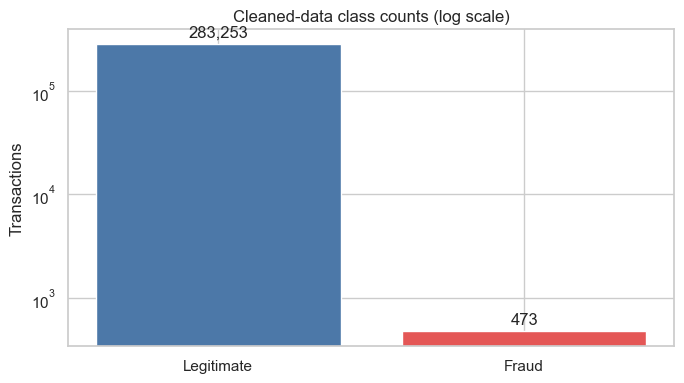

In [6]:
class_counts = df["Class"].value_counts().sort_index()
class_rates = df["Class"].value_counts(normalize=True).sort_index()
class_table = pd.DataFrame({"Count": class_counts, "Share": class_rates}).rename(index=LABELS)
print(class_table.to_string())
print(f"Frauds per 100,000 transactions: {df['Class'].mean() * 100_000:.1f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_table.index, class_table["Count"], color=[CLASS_COLORS[0], CLASS_COLORS[1]])
ax.set_yscale("log")
ax.set_title("Cleaned-data class counts (log scale)")
ax.set_ylabel("Transactions")
ax.bar_label(bars, labels=[f"{value:,}" for value in class_table["Count"]], padding=3)
plt.tight_layout()
plt.show()


## Transaction amount

The table reports the count, average, median, minimum, and maximum transaction amount for each class. Fraud transactions have a higher average amount than legitimate transactions (123.87 versus 88.41), but a lower median (9.82 versus 22.00). This contrast shows that the amount distributions are skewed and that the average alone does not describe a typical transaction. The boxplot therefore complements the average comparison. Outlier markers are hidden for readability.


             Count  Average  Median  Minimum     Maximum
Class                                                   
Legitimate  283253  88.4136 22.0000   0.0000 25,691.1600
Fraud          473 123.8719  9.8200   0.0000  2,125.8700


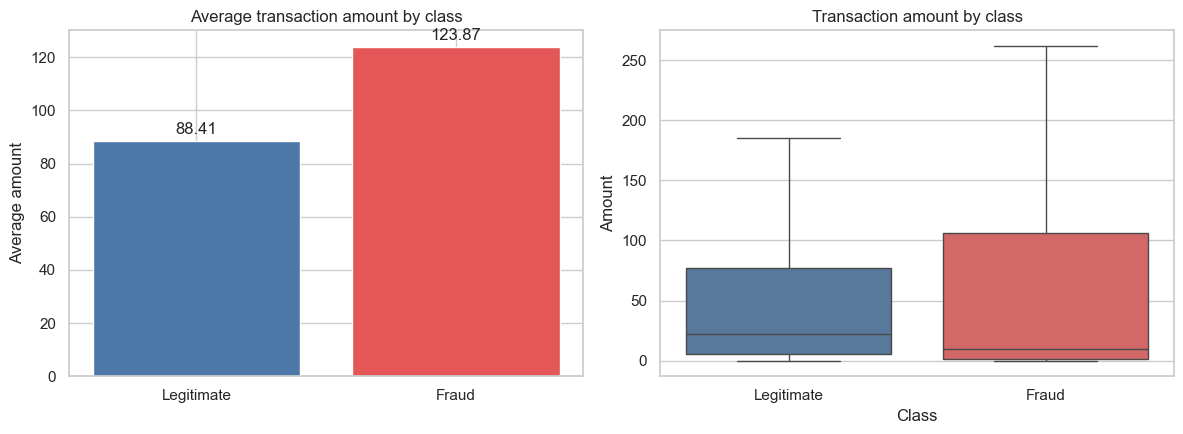

In [7]:
amount_summary = (
    df.groupby("Class")["Amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index=LABELS, columns={
        "count": "Count",
        "mean": "Average",
        "median": "Median",
        "min": "Minimum",
        "max": "Maximum",
    })
)
print(amount_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(
    amount_summary.index,
    amount_summary["Average"],
    color=[CLASS_COLORS[0], CLASS_COLORS[1]],
)
axes[0].set(title="Average transaction amount by class", ylabel="Average amount")
axes[0].bar_label(
    bars,
    labels=[f"{value:,.2f}" for value in amount_summary["Average"]],
    padding=3,
)

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    hue="Class",
    palette=CLASS_COLORS,
    showfliers=False,
    legend=False,
    ax=axes[1],
)
axes[1].set(title="Transaction amount by class", xlabel="Class", ylabel="Amount")
axes[1].set_xticks([0, 1], [LABELS[0], LABELS[1]])

plt.tight_layout()
plt.show()


### Fraud rate across transaction amount ranges

The overall amount summaries can hide nonlinear patterns. Transactions are therefore divided into four groups containing approximately equal numbers of observations. Each group is labeled with its actual dollar range. Comparing the fraud percentage within these ranges asks whether fraud is concentrated in particular parts of the amount distribution rather than assuming that risk rises steadily with transaction size.


     Amount_range  Transactions  Frauds  Fraud_rate
      $0.00–$5.60         70940     213      0.0030
     $5.60–$22.00         71035      47      0.0007
    $22.00–$77.51         70820      45      0.0006
$77.51–$25,691.16         70931     168      0.0024


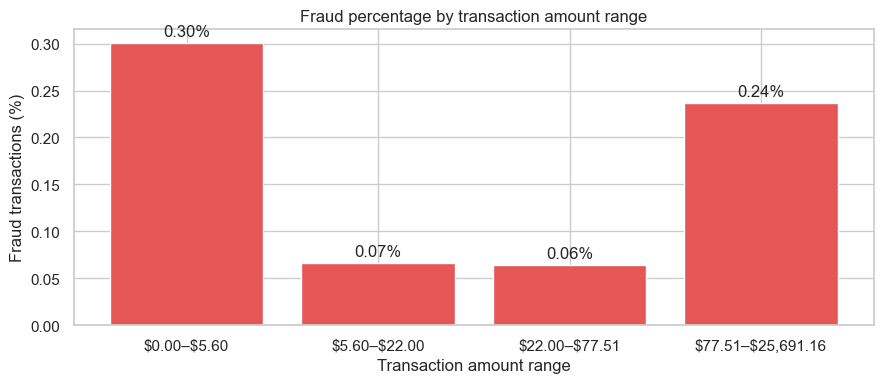

In [8]:
amount_group = pd.qcut(df["Amount"], q=4)

amount_risk = (
    df.assign(Amount_group=amount_group)
    .groupby("Amount_group", observed=True)
    .agg(
        Transactions=("Class", "size"),
        Frauds=("Class", "sum"),
        Fraud_rate=("Class", "mean"),
    )
    .reset_index()
)

# qcut slightly extends the first interval below zero so the minimum value is included.
# max(interval.left, 0) keeps the displayed range consistent with the observed data.
amount_risk["Amount_range"] = [
    f"${max(interval.left, 0):,.2f}–${interval.right:,.2f}"
    for interval in amount_risk["Amount_group"]
]

display_columns = ["Amount_range", "Transactions", "Frauds", "Fraud_rate"]
print(amount_risk[display_columns].to_string(index=False))

# Escape dollar signs so Matplotlib does not interpret them as math notation.
amount_plot_labels = [
    label.replace("$", r"\$")
    for label in amount_risk["Amount_range"]
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    amount_plot_labels,
    amount_risk["Fraud_rate"] * 100,
    color=CLASS_COLORS[1],
)

ax.set(
    title="Fraud percentage by transaction amount range",
    xlabel="Transaction amount range",
    ylabel="Fraud transactions (%)",
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in amount_risk["Fraud_rate"] * 100
    ],
    padding=3,
)

plt.tight_layout()
plt.show()

## Elapsed time

`Time` is the number of seconds since the first recorded transaction. The actual start time is not known, so the plots use elapsed hours rather than labels such as “hour of day.” The same 40 time bins are used for all transactions, fraud transactions, and the fraud rate. Dividing fraud counts by total transaction counts distinguishes an increase in fraud prevalence from an increase caused only by heavier transaction volume.

The observed bin-level fraud rate ranges from approximately 0.03% to 1.37%, compared with an overall rate of 0.17%. Because fraud is rare, individual bins can contain few fraud cases, so short-lived spikes do not conclusively show that fraud definitely occurs more at certain times. 


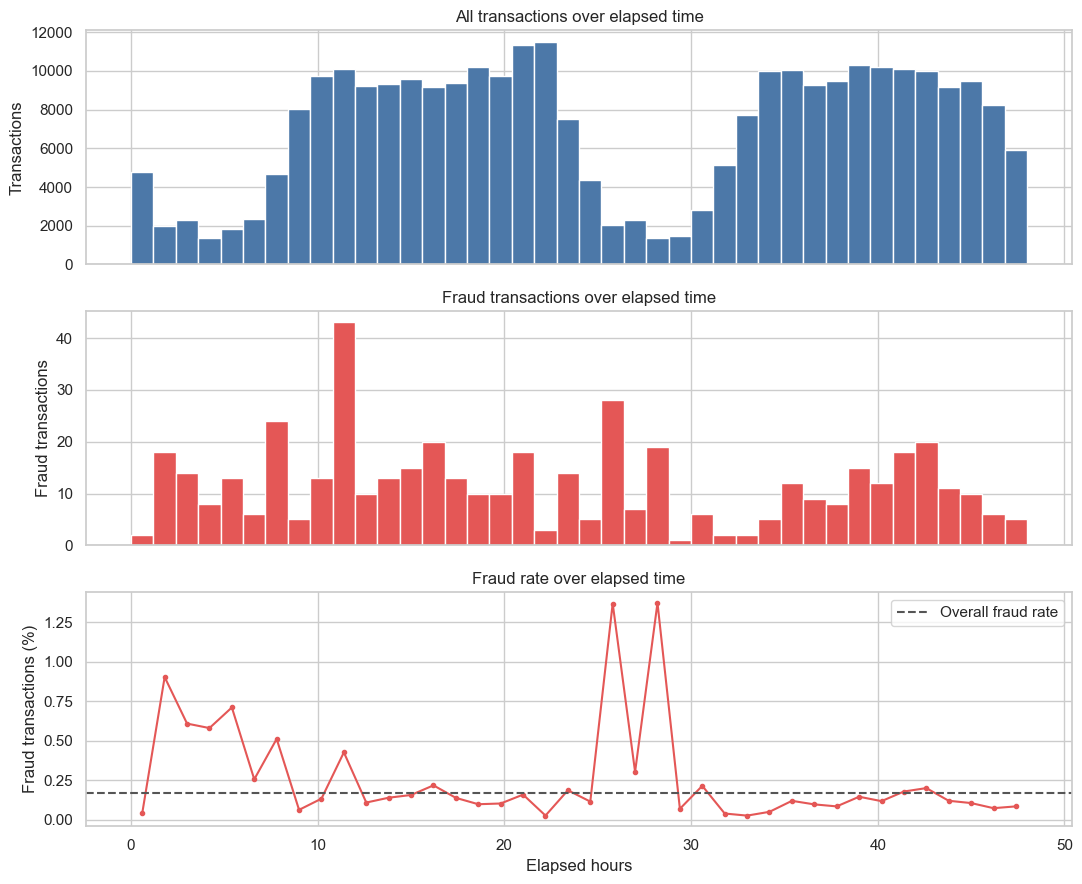

In [9]:
elapsed_hours = df["Time"] / 3600
fraud_hours = df.loc[df["Class"] == 1, "Time"] / 3600

time_bins = np.linspace(elapsed_hours.min(), elapsed_hours.max(), 41)
all_counts, bin_edges = np.histogram(elapsed_hours, bins=time_bins)
fraud_counts, _ = np.histogram(fraud_hours, bins=time_bins)

fraud_rate = np.divide(
    fraud_counts,
    all_counts,
    out=np.zeros_like(fraud_counts, dtype=float),
    where=all_counts > 0,
) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].hist(elapsed_hours, bins=time_bins, color=CLASS_COLORS[0], edgecolor="white")
axes[0].set(title="All transactions over elapsed time", ylabel="Transactions")

axes[1].hist(fraud_hours, bins=time_bins, color=CLASS_COLORS[1], edgecolor="white")
axes[1].set(title="Fraud transactions over elapsed time", ylabel="Fraud transactions")

axes[2].plot(bin_centers, fraud_rate, color=CLASS_COLORS[1], marker="o", markersize=3)
axes[2].axhline(
    df["Class"].mean() * 100,
    color="#555555",
    linestyle="--",
    label="Overall fraud rate",
)
axes[2].set(
    title="Fraud rate over elapsed time",
    xlabel="Elapsed hours",
    ylabel="Fraud transactions (%)",
)
axes[2].legend()

plt.tight_layout()
plt.show()


## PCA feature distributions

Class-wise medians and interquartile ranges compare the centers and spreads of the anonymized PCA features without being overly influenced by extreme observations. Absolute median difference is used to identify a manageable set of six features for visualization. It is a descriptive ranking, not a formal feature-importance or feature-selection method.

The largest median differences occur for `V14`, `V12`, `V17`, `V3`, `V10`, and `V4`. Fraud transactions have lower medians for the first five and a higher median for `V4`. The boxplots show how much the two classes still overlap and whether their spreads also differ. Because the components are anonymized, no business meanings are assigned to them.


In [10]:
legitimate_features = df.loc[df["Class"] == 0, pca_cols]
fraud_features = df.loc[df["Class"] == 1, pca_cols]

median_comparison = pd.DataFrame({
    "Legitimate median": legitimate_features.median(),
    "Fraud median": fraud_features.median(),
    "Median difference (fraud - legitimate)": fraud_features.median() - legitimate_features.median(),
    "Legitimate IQR": legitimate_features.quantile(0.75) - legitimate_features.quantile(0.25),
    "Fraud IQR": fraud_features.quantile(0.75) - fraud_features.quantile(0.25),
})
median_comparison["Absolute median difference"] = median_comparison["Median difference (fraud - legitimate)"].abs()
median_comparison = median_comparison.sort_values("Absolute median difference", ascending=False)

print(median_comparison.head(10).to_string())


     Legitimate median  Fraud median  Median difference (fraud - legitimate)  Legitimate IQR  Fraud IQR  Absolute median difference
V14             0.0515       -6.5906                                 -6.6420          0.9158     5.2527                      6.6420
V12             0.1406       -5.4374                                 -5.5779          1.0207     5.7767                      5.5779
V17            -0.0651       -5.1576                                 -5.0925          0.8820    10.4595                      5.0925
V3              0.1822       -4.8754                                 -5.0576          1.9122     5.7551                      5.0576
V10            -0.0921       -4.4663                                 -4.3742          0.9879     4.8503                      4.3742
V4             -0.0245        4.1001                                  4.1246          1.5858     4.0023                      4.1246
V11            -0.0344        3.5257                                  3.5602

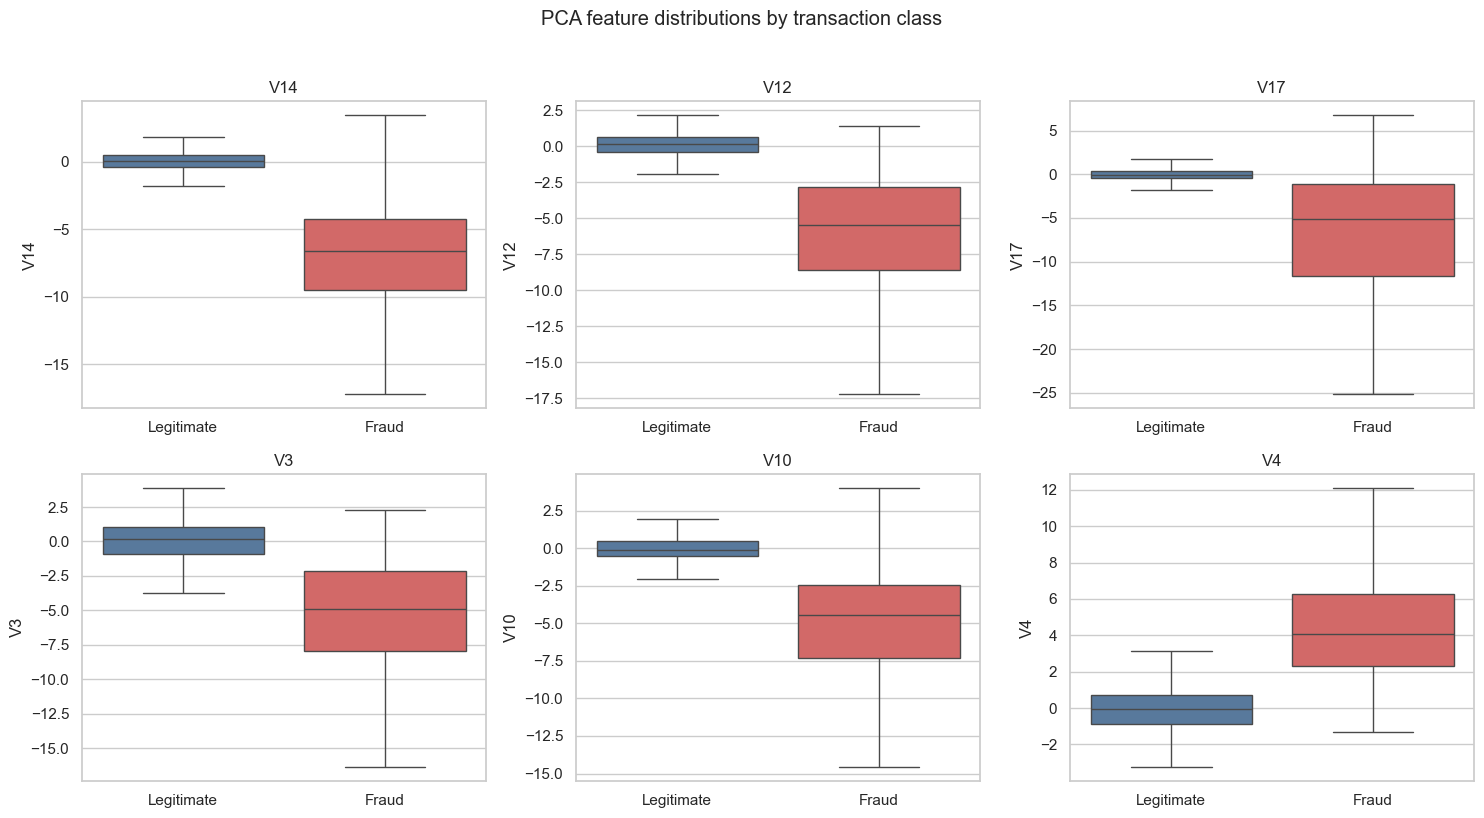

In [11]:
features_to_plot = median_comparison.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for feature, ax in zip(features_to_plot, axes.flat):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        hue="Class",
        palette=CLASS_COLORS,
        showfliers=False,
        legend=False,
        ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_xticks([0, 1], [LABELS[0], LABELS[1]])

fig.suptitle("PCA feature distributions by transaction class", y=1.02)
plt.tight_layout()
plt.show()


All cleaned transactions are used in the PCA boxplots. Individual outlier markers are hidden so the boxes remain readable, but the underlying calculations and plots still use every row. Visible overlap between classes is expected: a difference in typical values does not imply that any single feature perfectly identifies fraud.


### Predictor correlations

Pearson correlation measures the strength and direction of linear relationships between pairs of predictors. The heatmap provides the complete pattern, while the table makes the ten strongest non-self relationships easier to read. Pairs are ranked by absolute correlation so strong positive and negative relationships are both included. `Class` is excluded because this section examines relationships among predictors rather than predictor–outcome association.

The strongest relationships are between `V2` and `Amount` (−0.53), `Time` and `V3` (−0.42), and `V7` and `Amount` (+0.40). These values indicate moderate linear relationships.


Ten largest off-diagonal predictor correlations (ranked by absolute value):
Feature 1 Feature 2  Correlation  Absolute correlation
       V2    Amount      -0.5334                0.5334
     Time        V3      -0.4221                0.4221
       V7    Amount       0.4004                0.4004
       V5    Amount      -0.3877                0.3877
      V20    Amount       0.3407                0.3407
     Time       V11      -0.2485                0.2485
     Time       V25      -0.2333                0.2333
       V1    Amount      -0.2301                0.2301
       V6    Amount       0.2164                0.2164
       V3    Amount      -0.2124                0.2124


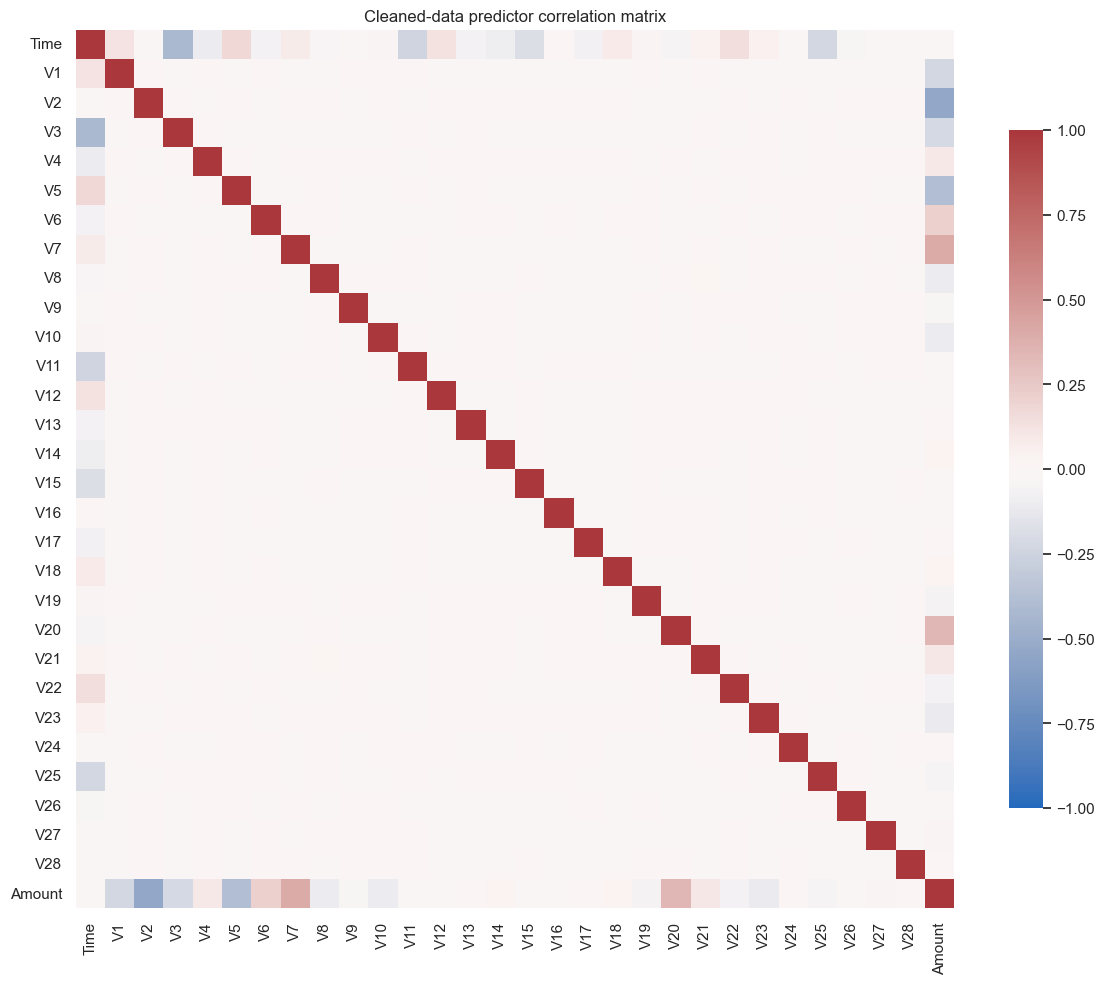

In [12]:
corr_cols = ["Time", *pca_cols, "Amount"]
corr = df[corr_cols].corr()

# Keep only the upper triangle so each feature pair appears once and self-correlations are excluded.
upper_triangle = np.triu(np.ones(corr.shape, dtype=bool), k=1)
correlation_pairs = (
    corr.where(upper_triangle)
    .stack()
    .rename("Correlation")
    .reset_index()
)
correlation_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
correlation_pairs["Absolute correlation"] = correlation_pairs["Correlation"].abs()
top_correlations = correlation_pairs.sort_values(
    "Absolute correlation",
    ascending=False,
).head(10)

print("Ten largest off-diagonal predictor correlations (ranked by absolute value):")
print(top_correlations.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=True,
    yticklabels=True,
    ax=ax,
    cbar_kws={"shrink": 0.75},
)
ax.set_title("Cleaned-data predictor correlation matrix")
plt.tight_layout()
plt.show()


## Cleaning decisions and modeling implications

The data-quality and exploratory analysis led to the following decisions:

- **Missing and non-finite values:** No missing or non-finite values were found, so no missing-value treatment is required.

- **Duplicate records:** The dataset contained 1,081 exact duplicate records beyond their first occurrence, including 19 fraud records. These duplicates were removed to prevent repeated transactions from influencing the analysis and later modeling.

- **Extreme values:** Extreme values were observed in `Amount` and several PCA components. These observations were retained because unusual transactions may contain important fraud-related information.

- **Class imbalance:** Fraud accounts for only 0.1667% of the cleaned dataset. Therefore, later models will be evaluated using metrics and strategies such as precision, recall, F1-score, and a precision-recall curve rather than accuracy alone.

- **Anonymized features:** Several PCA components show different distributions and medians for legitimate and fraudulent transactions. Multiple model types will be compared, but no real-world meanings will be assigned since they are anonymized features. 